In [1]:
#BUILDING A NEURAL NETWORK FOR SPAM DETECTION
import numpy as np 
import pandas as pd
import re #used to find and replace text patterns
import nltk #Provifes natural language processing toolkits
nltk.download("stopwords")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud #Generates visualization for words
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JANE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
message_dataset = pd.read_csv('emails.csv', engine = 'python')
message_dataset.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
#show total emails in the dataset
message_dataset.shape

(5728, 2)

<Axes: ylabel='count'>

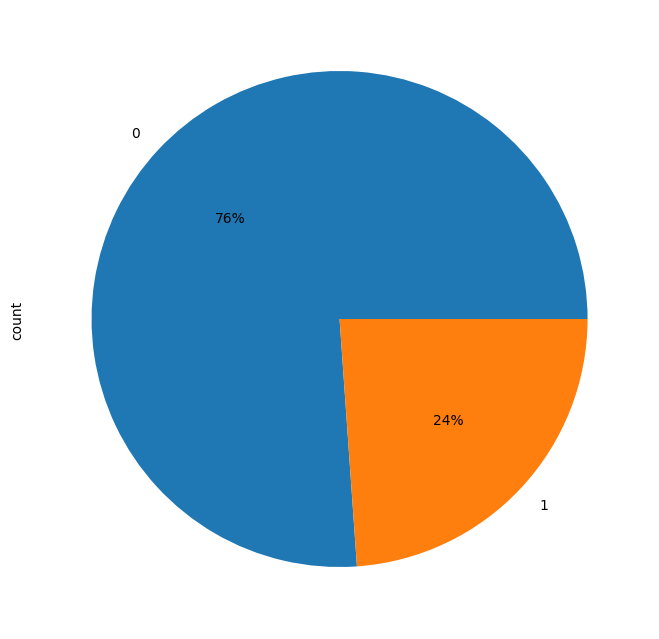

In [4]:
#DATA VISUALIZATION
plt.rcParams["figure.figsize"]=[8,10]
message_dataset.spam.value_counts().plot(kind='pie', autopct = '%1.0f%%')
#counts how many times the word spam occurs in the label (1 = spam, 0 = not spam)

In [5]:
#REMOVING COMMON ENGLISH WORDS TO GET MOST OCCURING WORDS IN SPAM AND NOT SPAM EMAILS
from nltk.corpus import stopwords
stop = stopwords.words('english')#retrive english words

message_dataset['text_without_sw'] = message_dataset['text'].apply(lambda x:' '.join([item for item in x.split() if item not in stop]))

# select the og email text column and then applies the lambda function to 
# each email and splits each word individially and keeps words not in the stopwords list 

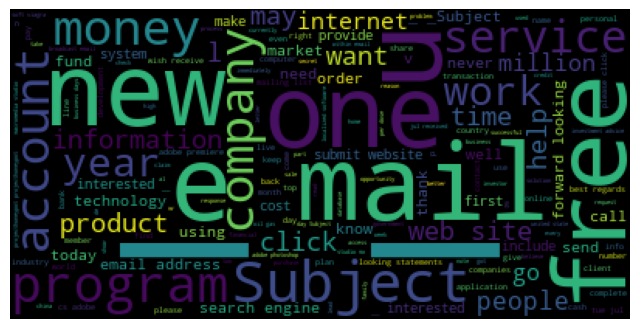

In [6]:
#FILTERS SPAM MESSAGES AND PLOTS WORD CLOUD USING SPAM EMAILS
message_dataset_spam = message_dataset[message_dataset["spam"]==1]#boolean indexing to get spam rows

plt.rcParams["figure.figsize"] = [8,10]
text = ''.join(message_dataset_spam['text_without_sw'])
wordcloud2 = WordCloud().generate(text) #analyzes word frequencies and produces image

plt.imshow(wordcloud2) #displays image
plt.axis("off") #hides axis
plt.show()


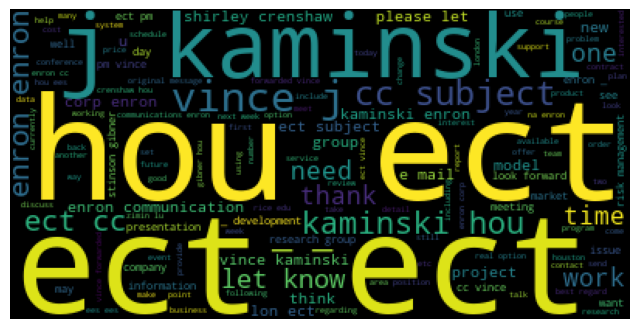

In [7]:
#FILTERS NOT SPAM MESSAGES AND PLOTS WORD CLOUD USING NOT SPAM EMAILS
message_dataset_spam = message_dataset[message_dataset["spam"]==0]#boolean indexing to get spam rows

plt.rcParams["figure.figsize"] = [8,10]
text = ''.join(message_dataset_spam['text_without_sw'])
wordcloud2 = WordCloud().generate(text) #analyzes word frequencies and produces image

plt.imshow(wordcloud2) #displays image
plt.axis("off") #hides axis
plt.show()

In [8]:
#CLEANING THE DATA: REMOVING SPECIAL CHARACTERS AND NUMBERS FROM TEXT
X = message_dataset["text"] #feature set(input)
y = message_dataset["spam"] #target: info about email = spam/not spam (output)

In [9]:
#Clean text from digits, special characters and multiple empty spaces
def clean_text(doc):
    
    document = re.sub('[^a-zA-Z]', ' ',doc) #removes all characters that are not letters and replaces them with a space
    document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document) #removes all single characters that are surrounded by spaces and replaces them with a space
    document = re.sub(r'\s+', ' ',document)# replaces multiple spaces with a single space
    return document

In [10]:
X_sentences = [] #Empty list
reviews = list(X) #Convert the text column to a list
for rev in reviews: 
    X_sentences.append(clean_text(rev))

In [ ]:
#CONVERT TEXT TO NUMBERS cause Naive Bayes is a stat algorithm that works with numbers
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer #Vector that represents a word's importance

vectorizer = TfidfVectorizer(max_features = 2500, min_df = 5, max_df = 0.7,
stop_words = stopwords.words('english')) # get maximum of 2500 most used words that appear in no less than 5 times, not more than 70% of documents 
#and remove common english words
X = vectorizer.fit_transform(X_sentences).toarray()#fits all documents to tfidf vector

In [ ]:
#TRAINING THE MODEL. DIVIDE DATA INTO TRAINING AND TEST SETS BETWEEN EMAIL TEXT AND LABLE(SPAM/NOT SPAM)